# 长上下文外推

> 我们已经知道，LLaMA 2 训练时的上下文长度只有 4096 个 token。但今天同一个架构的模型已经能稳定处理 32000、128000 甚至 100 万个 token。这些提升不是靠重新训练实现的——重新训练的成本太高。
>
> 这一节，我们从 Attention 的长度瓶颈出发，理解 RoPE 为什么能外推、位置插值（PI）做了什么、NTK 和 YaRN 又在此基础上改进了什么，最后学会测试一个模型的长上下文能力。

长上下文外推（Length Extrapolation）要解决的问题可以这样描述：模型在训练时只见过位置 0 到 4095 的编码，推理时你要求它处理位置 10000——这个位置的编码对模型来说是陌生的，Attention 的行为会失控。解决方案不是重新训练（那等于从头再来），而是找到一种方法，让训练时学到的位置编码规律能够在更长的序列上继续生效。RoPE 本身有一定外推能力，因为它是用旋转矩阵编码相对位置；PI 把长序列的位置编号「压缩」回训练区间；NTK 调整了 RoPE 的频率基；YaRN 在 NTK 基础上对不同频率的维度做了不同处理。下面从最基础的 Attention 长度公式开始，逐步推演每种方法的动机。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

torch.manual_seed(42)

## 1. 什么是外推

**外推**（Extrapolation）= 用已知范围的规律，推测范围之外的情况。

举个生活中的例子：
- 你测过水温 0°C → 冰，50°C → 液体，100°C → 沸腾
- 现在问你：200°C 的水会怎样？你虽然没测过，但根据规律能推断 → 还是气体
- 这就是「外推」

LLM 面临同样的问题：
- 训练时：模型学习了位置 0 到 4095 之间的 attention 规律
- 推理时：用户给了一篇 10000 token 的文章
- 问题：位置 4096~9999 这些位置的 token，模型训练时从没见过，它能正确处理它们吗？

**答案取决于你用什么位置编码。**

## 2. 位置编码回顾

（如果你对 Part 3 的 Embedding + Position 已经很熟，可以跳过这一节。但后面的 RoPE 依赖这个基础，不确定的话最好看一眼。）

Attention 本身是**不关心顺序**的。你把 "猫 坐 垫子" 和 "垫子 坐 猫" 喂给 attention，它算出来的 attention 分数完全相同——因为 attention 只看 token 之间「有多相关」，不看「谁在前谁在后」。

但顺序显然很重要。「我爱你」和「你爱我」意思完全不同。

**位置编码就是给每个 token 贴上一个「我是第几个」的标签**，让 attention 在计算相关性时能用到这个信息。

贴标签有三种方式：

In [2]:
# 直观感受：顺序对 attention 的影响
print("句子 A: 我 爱 你")
print("句子 B: 你 爱 我")
print()
print("没有位置编码时：")
print("  '我' 和 '你' 的 attention 分数完全一样——不管谁在前面")
print("  模型分不清 '我爱你' 和 '你爱我'")
print()
print("有位置编码时：")
print("  '我' 在位置 0 和位置 2 有不同的向量 → attention 可以区分")
print()
print("问题来了：训练时最长只见过 4096 个位置，")
print("推理时来了 10000 个位置 → 第 4097 个位置的「标签」长什么样？")

句子 A: 我 爱 你
句子 B: 你 爱 我

没有位置编码时：
  '我' 和 '你' 的 attention 分数完全一样——不管谁在前面
  模型分不清 '我爱你' 和 '你爱我'

有位置编码时：
  '我' 在位置 0 和位置 2 有不同的向量 → attention 可以区分

问题来了：训练时最长只见过 4096 个位置，
推理时来了 10000 个位置 → 第 4097 个位置的「标签」长什么样？


## 3. 三种位置编码的外推能力

| 方案 | 怎么做 | 代表模型 | 能外推吗？ | 为什么？ |
|------|--------|---------|----------|--------|
| **学出来的位置** | 训练时给每个位置随机初始化一个向量，训练过程中调整 | GPT-2 | ❌ 完全不能 | 只学了 0~1023 位置的向量，1024 位置的向量根本没存在过 |
| **正弦位置编码** | 用 sin/cos 函数手工算每个位置的值，不用学 | 原始 Transformer | 理论上能，实际很差 | 函数本身连续，但模型没学会利用连续性 |
| **RoPE（旋转位置编码）** | 用「旋转」来编码位置，位置差 = 旋转角度差 | LLaMA、Qwen、Mistral | ✅ **可以！** | 相对位置天然具有外推性，且频域特性可以利用 |

RoPE 现在是几乎所有开源 LLM 的标配。我们下面搞懂它。

## 4. RoPE 的直觉

想象一个时钟。不是普通的 12 小时钟，而是一个「位置钟」：

- 位置 0 的 token → 指针指向 12 点（0°）
- 位置 1 的 token → 指针顺时针转一点（比如 30°）
- 位置 2 的 token → 再转一点（60°）
- ...

**关键：RoPE 不是给每个位置加一个值，而是把 token 的向量「旋转」一下。**

```
正弦方案：token 向量 + 位置向量 = 最终向量（加法）
RoPE 方案：让 token 向量转动一个角度 = 最终向量（旋转）
```

为什么旋转更好？**因为旋转角度的差 = 相对位置。**

两个向量转完之后做点积，结果只取决于它们旋转角度的**差**：
- 位置 0 和位置 1：角度差 30° → 点积 = cos(30°)
- 位置 5 和位置 6：角度差也是 30° → 点积 = 也是 cos(30°)
- 位置 0 和位置 3：角度差 90° → 点积 = cos(90°)

**相邻的两个 token，不管在句子开头还是结尾，它们之间的 attention 都一样！** 这个性质非常重要。

## 5. RoPE 的计算过程

不跳过任何一步。

#### Step 1：把向量拆成一对一对的「二维向量」

一个 token 的向量有 d_k 维，比如 64 维。我们把它两两分组：(第0维, 第1维)、(第2维, 第3维)、...、(第62维, 第63维)。共 32 对。

每一对就是一个二维平面上的坐标 `(x, y)`。**旋转就是在这个平面上转。**

#### Step 2：每对维度有不同的旋转速度

第 0 对维度转得**快**（每个位置转一大步）→ 负责区分相邻位置
第 31 对维度转得**慢**（每个位置只转一点点）→ 负责长距离信息

这就好比：
- **秒针**（高频）：转得快，区分"刚刚"和"现在"
- **分针**（中频）：转得慢一些，区分"几分钟前"
- **时针**（低频）：转得最慢，区分"几小时前"

数学上，第 i 对维度的旋转速度（频率）是：
```
freq_i = 1 / base^(2i/d)
```
其中 `base` 默认是 10000。i 越大，分母越大，频率越小 → 转得越慢。

In [3]:
# 直接看：不同维度对的旋转速度差多少
d_k = 64          # 总共 64 维，两两结对 → 32 对
base = 10000      # RoPE 默认 base

pair_indices = torch.arange(0, d_k, 2).float()  # [0, 2, 4, ..., 62]
freqs = 1.0 / (base ** (pair_indices / d_k))

print(f"共 {len(freqs)} 对维度")
print(f"第 0 对（最快）频率: {freqs[0]:.4f}  → 每位置转 {math.degrees(freqs[0]):.1f}°")
print(f"第 16 对（中等）频率: {freqs[16]:.6f}  → 每位置转 {math.degrees(freqs[16]):.4f}°")
print(f"第 31 对（最慢）频率: {freqs[31]:.8f}  → 每位置转 {math.degrees(freqs[31]):.6f}°")

slowest_period = 2 * math.pi / freqs[31]
print(f"\n最慢那对走完一圈需要 {slowest_period:.0f} 个位置")
# → 训练窗口 4096，最慢的指针连一圈都没走完 → 这就是外推的瓶颈

共 32 对维度
第 0 对（最快）频率: 1.0000  → 每位置转 57.3°
第 16 对（中等）频率: 0.010000  → 每位置转 0.5730°
第 31 对（最慢）频率: 0.00013335  → 每位置转 0.007641°

最慢那对走完一圈需要 47117 个位置


/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49974/1492510485.py:19: UserWarning: Glyph 24555 (\N{CJK UNIFIED IDEOGRAPH-5FEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49974/1492510485.py:19: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49974/1492510485.py:19: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49974/1492510485.py:19: UserWarning: Glyph 38024 (\N{CJK UNIFIED IDEOGRAPH-9488}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn6r25n41j9fm98mh1l73hm0000gn/T/ipykernel_49974/1492510485.py:19: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/fv/xkn

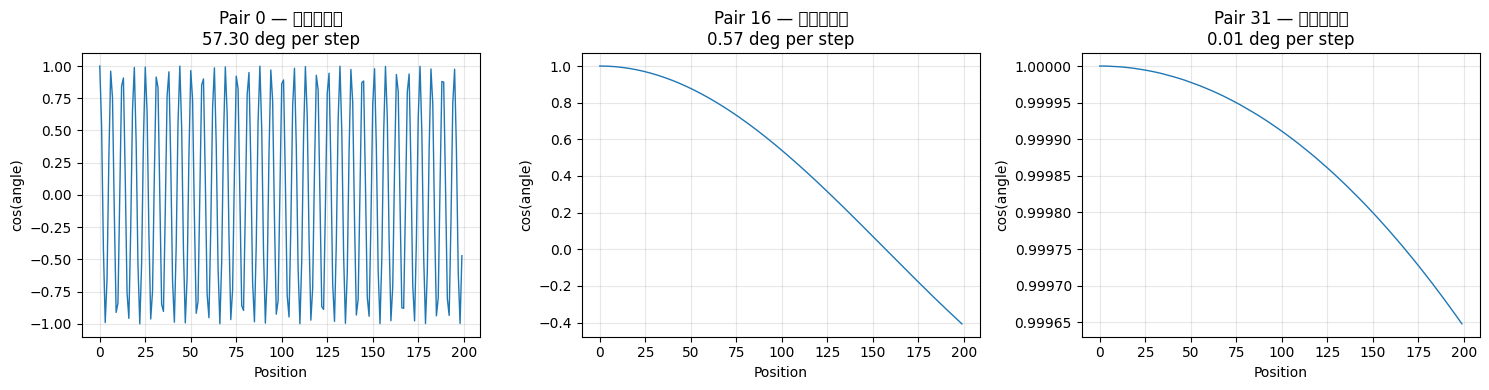

In [4]:
# 画出来：不同维度的指针随位置移动（cos 值）
seq_len = 200
positions = torch.arange(seq_len).float()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax_idx, (pair_idx, label) in enumerate([
    (0, "快（秒针）"),
    (16, "中（分针）"),
    (31, "慢（时针）")
]):
    theta = positions * freqs[pair_idx]
    ax = axes[ax_idx]
    ax.plot(positions.numpy(), theta.cos().numpy(), linewidth=1)
    ax.set_xlabel('Position'); ax.set_ylabel('cos(angle)')
    ax.set_title(f'Pair {pair_idx} — {label}\n{math.degrees(freqs[pair_idx]):.2f} deg per step')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# 左边转了好几圈（密集波形）→ 高频 → 区分邻居
# 右边不到半圈（缓慢曲线）→ 低频 → 承载远距离信息


## 6. 直接外推的失败原因

训练窗口是 4096。现在推理时来了 8192 个 token。**直接告诉 RoPE「继续往后数，位置 4097, 4098, ...」行不行？**

不行。看低频维度（最慢的那个指针）：

- 训练时：它只在 0~4095 这个范围内转过，见过的是 cos(θ) 其中 θ 在 [0, 某个范围内]
- 推理时到了位置 8192：θ = 8192 × freq，这个 θ 值超出了训练见过的范围
- 模型对超出的 θ 值没有经验 → attention 算错 → 输出乱码

**类比：你只学过 sin(0°) 到 sin(45°) 的值，然后让你算 sin(180°)，你懵了。**

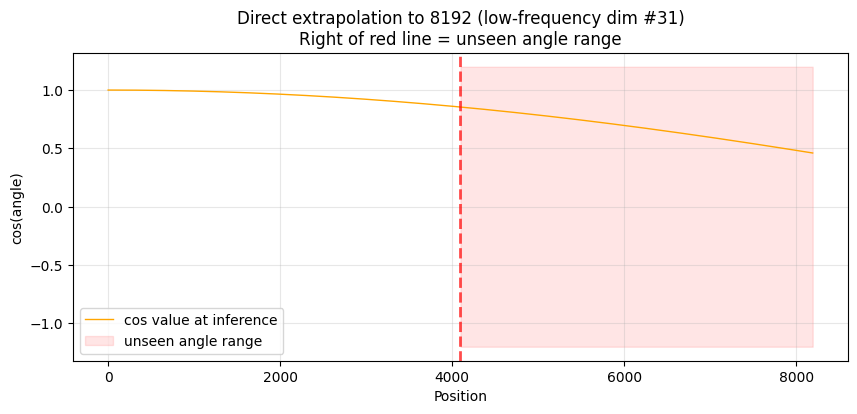

训练时最大角度: 31.3°  →  外推后最大角度: 62.6°  →  超出 31.3°


In [5]:
# 直接外推的问题：低频维度在训练窗口外角度超标
train_len, extrap_len = 4096, 8192
slow_pair = 31

positions_train = torch.arange(train_len).float()
positions_extrap = torch.arange(extrap_len).float()
theta_train = positions_train * freqs[slow_pair]
theta_extrap = positions_extrap * freqs[slow_pair]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(positions_extrap.numpy(), theta_extrap.cos().numpy(),
        linewidth=1, color='orange', label='cos value at inference')
ax.axvline(x=train_len, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.fill_between(range(train_len, extrap_len), -1.2, 1.2,
                alpha=0.1, color='red', label='unseen angle range')
ax.set_xlabel('Position'); ax.set_ylabel('cos(angle)')
ax.set_title(f'Direct extrapolation to 8192 (low-frequency dim #{slow_pair})\nRight of red line = unseen angle range')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

# 训练时角度 0~{train_deg:.0f}°，外推时到了 {extrap_deg:.0f}°，超出 {over:.0f}°
train_deg = math.degrees(theta_train[-1].item())
extrap_deg = math.degrees(theta_extrap[-1].item())
print(f"训练时最大角度: {train_deg:.1f}°  →  外推后最大角度: {extrap_deg:.1f}°  →  超出 {extrap_deg - train_deg:.1f}°")


## 7. 核心思想：角度映射

既然模型只认识 0~4095 位置对应的角度，那我们想办法让位置 4096~8191 产生的角度也落在训练范围内，不就行了？

```
原始 RoPE（直接外推 → 失败）:
  位置 0    → 角度 0°         ✅ 模型认识
  位置 4096 → 角度 1000°      ❌ 不认识！没学过
  位置 8192 → 角度 2000°      ❌ 更不认识！

外推后的 RoPE（角度压缩 → 成功）:
  位置 0    → 角度 0°         ✅ 认识
  位置 4096 → 角度 500°       ✅ 认识！（压缩到了训练范围内）
  位置 8192 → 角度 1000°      ✅ 认识！
```

**核心操作就是一句话：通过某种方式，让超长位置产生的旋转角度不超过训练时见过的角度范围。**

剩下的问题是：「怎么压缩」最合理？下面看三种方法。

## 8. 方法一：Position Interpolation

**论文**: Meta, 2023 — Extending Context Window via Position Interpolation

想法：把位置编号直接**等比例压缩**。

```
目标: 把 4096 窗口扩展到 8192
缩放因子 α = 4096 / 8192 = 0.5

新位置 = 真实位置 × 0.5

真实位置 0    → 给模型的位置 = 0 × 0.5 = 0
真实位置 2048 → 给模型的位置 = 2048 × 0.5 = 1024
真实位置 8192 → 给模型的位置 = 8192 × 0.5 = 4096 ← 刚好落在训练边界！
```

**打个比方**：你家门牌号是 1 到 100 号，你只认识 1-50 号。现在来了 51-100 号，你把所有号码除以 2——51 号变成 25.5 号，100 号变成 50 号，全都在你认识的范围内。

**代价**：所有门牌号都被压缩了。原来能清楚区分 1 号和 2 号，现在 1 号和 2 号变成了 0.5 号和 1 号，差别变小了——近程分辨力下降。

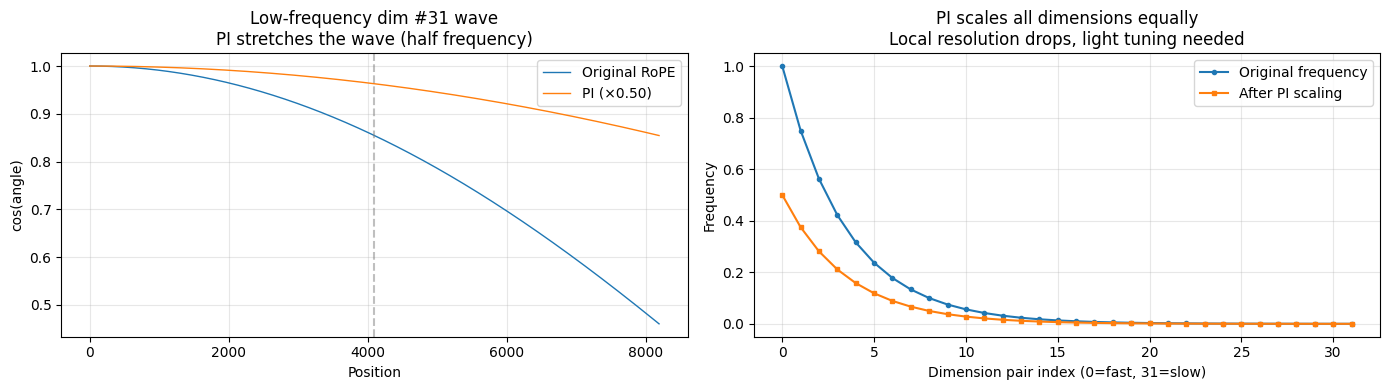

In [6]:
# PI 的实现：位置 × 缩放因子，再正常算 RoPE
train_len, target_len = 4096, 8192
alpha = train_len / target_len  # 0.5

pair_indices = torch.arange(0, 64, 2).float()
freqs_orig = 1.0 / (10000 ** (pair_indices / 64))
freqs_pi = freqs_orig * alpha

# 原始 RoPE vs PI 压缩后的波形
positions_orig = torch.arange(target_len).float()
angles_orig = positions_orig * freqs_orig[31]
positions_pi = torch.arange(target_len).float() * alpha
angles_pi = positions_pi * freqs_orig[31]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(angles_orig.cos().numpy(), linewidth=1, label='Original RoPE')
axes[0].plot(angles_pi.cos().numpy(), linewidth=1, label=f'PI (×{alpha:.2f})')
axes[0].axvline(x=train_len, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Position'); axes[0].set_ylabel('cos(angle)')
axes[0].set_title(f'Low-frequency dim #{31} wave\nPI stretches the wave (half frequency)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 右：所有维度频率被等比例压缩
axes[1].plot(freqs_orig.numpy(), 'o-', markersize=3, label='Original frequency')
axes[1].plot(freqs_pi.numpy(), 's-', markersize=3, label='After PI scaling')
axes[1].set_xlabel('Dimension pair index (0=fast, 31=slow)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('PI scales all dimensions equally\nLocal resolution drops, light tuning needed')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. 方法二：NTK-aware

**论文**: NTK-Aware Scaled RoPE, bloc97, 2023

PI 的毛病：它对**所有**维度一视同仁地压缩。但从第 5 节我们知道，不同维度转的速度不一样：
- 快的维度（秒针）：在 4096 个位置内已经转了好多圈，各种角度都见过了 → **不需要压缩**
- 慢的维度（时针）：4096 个位置内连一圈都没走完，没见过的角度多 → **需要压缩**

所以 NTK-aware 的想法是：**只压慢的，不压快的。**

怎么做到？**把 base 从 10000 改大。** 这是 NTK-aware 最巧妙的地方：

```
频率公式: freq_i = 1 / base^(2i/d)

base = 10000 → 频率快 → 慢维度也走不完一圈
base = 100000 → 频率变慢 → 慢维度走得更慢 → 在同样位置内角度更小 → 不超出训练范围！

而且：
  低 i（快维度）: freq ≈ 1 → 改 base 几乎不影响 ← 快的不用调
  高 i（慢维度）: freq ≈ 1/base → 改 base 影响大 ← 慢的调得多
```

这恰好实现了「快手不调，慢手多调」！**一个参数的改动，自动完成了差异化压缩。**

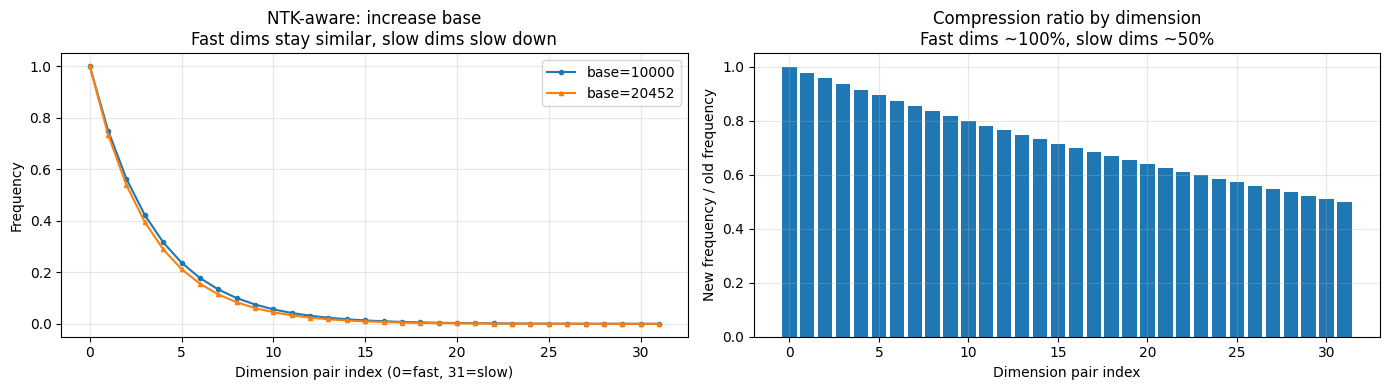

In [7]:
# 演示 NTK：改 base 对不同维度的影响
base_old, scale = 10000, 2
# NTK 公式：新 base = 旧 base × scale^(d/(d-2))
base_new = base_old * (scale ** (64 / 62))

pair_indices = torch.arange(0, 64, 2).float()
freqs_old = 1.0 / (base_old ** (pair_indices / 64))
freqs_new = 1.0 / (base_new ** (pair_indices / 64))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(freqs_old.numpy(), 'o-', markersize=3, label=f'base={base_old}')
axes[0].plot(freqs_new.numpy(), '^-', markersize=3, label=f'base={base_new:.0f}')
axes[0].set_xlabel('Dimension pair index (0=fast, 31=slow)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('NTK-aware: increase base\nFast dims stay similar, slow dims slow down')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 每个维度的压缩比
ratio = freqs_new / freqs_old
axes[1].bar(range(len(ratio)), ratio.numpy())
axes[1].set_xlabel('Dimension pair index'); axes[1].set_ylabel('New frequency / old frequency')
axes[1].set_title('Compression ratio by dimension\nFast dims ~100%, slow dims ~50%')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# NTK 只需把 base 从 10000 改到 ~86000，不改模型结构，大多数情况不需微调


## 10. 方法三：YaRN

**论文**: YaRN, 2023

NTK 已经很好了，但 YaRN 发现了一个问题：改 base 之后，中间那些维度（不快不慢的）的 attention 会变得「不够果断」。

什么意思？回想 attention 的 softmax 步骤：

```
softmax([2, 1, 0.5]) → [0.59, 0.22, 0.13, 0.06]  ← 比较「尖锐」，注意力集中
softmax([1, 0.5, 0.25]) → [0.42, 0.26, 0.19, 0.14] ← 比较「平滑」，注意力分散
```

用「温度」可以调节 softmax 的尖锐程度：
```
温度低 → softmax 更尖锐 → 注意力更集中 → 适合近程信息
温度高 → softmax 更平滑 → 注意力更分散 → 适合远程信息（反正远距离也不需要精确到哪个 token）
```

**YaRN 的做法：NTK 改 base + 对不同维度组用不同的 softmax 温度。**

- 快维度：温度 = 1（不调，保持精确）
- 中间维度：温度平滑过渡
- 慢维度：温度稍高（让远程 attention 更平滑）

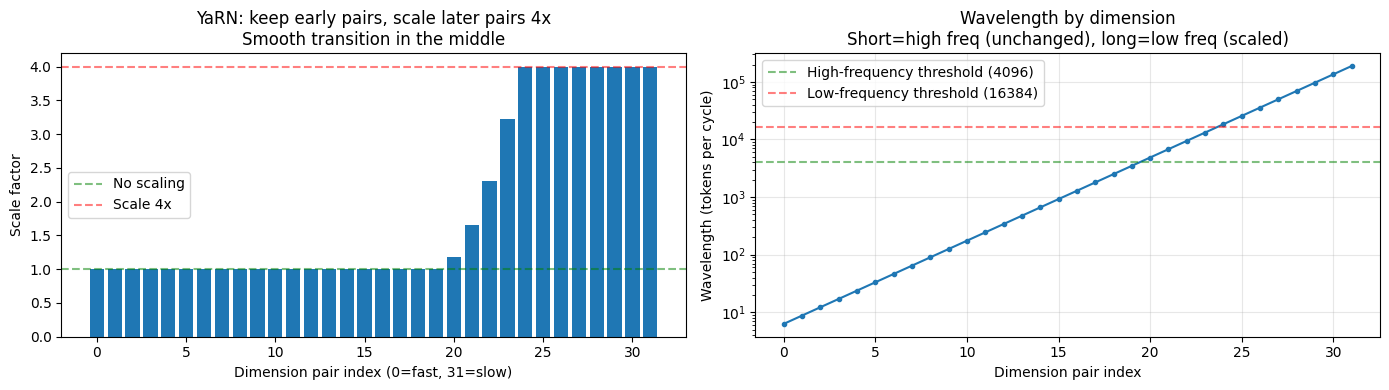

In [8]:
# YaRN 的分段策略：根据波长把维度分成三组
scale, target_len = 4, 16384
pair_indices = torch.arange(0, 64, 2).float()
base_new = 10000 * (scale ** (64 / 62))
freqs_new = 1.0 / (base_new ** (pair_indices / 64))
wavelengths = 2 * math.pi / freqs_new  # 走完一圈需要的位置数

# 分段阈值
low_bound = target_len / 1.0    # 波长 > 此值 → 低频（需缩放）
high_bound = target_len / 4.0   # 波长 < 此值 → 高频（不缩放）

# ramping: 从 0（不调）平滑过渡到 1（缩放 scale 倍）
smooth = torch.clamp((wavelengths - high_bound) / (low_bound - high_bound), 0.0, 1.0)
dim_scale = (1 - smooth) * 1.0 + smooth * scale

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(range(32), dim_scale.numpy())
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='No scaling')
axes[0].axhline(y=scale, color='red', linestyle='--', alpha=0.5, label=f'Scale {scale}x')
axes[0].set_xlabel('Dimension pair index (0=fast, 31=slow)'); axes[0].set_ylabel('Scale factor')
axes[0].set_title(f'YaRN: keep early pairs, scale later pairs {scale}x\nSmooth transition in the middle')
axes[0].legend()

axes[1].plot(wavelengths.numpy(), 'o-', markersize=3)
axes[1].axhline(y=high_bound, color='green', linestyle='--', alpha=0.5, label=f'High-frequency threshold ({high_bound:.0f})')
axes[1].axhline(y=low_bound, color='red', linestyle='--', alpha=0.5, label=f'Low-frequency threshold ({low_bound:.0f})')
axes[1].set_xlabel('Dimension pair index'); axes[1].set_ylabel('Wavelength (tokens per cycle)')
axes[1].set_yscale('log'); axes[1].set_title('Wavelength by dimension\nShort=high freq (unchanged), long=low freq (scaled)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# YaRN = NTK 改 base + 分段平滑过渡 ← 目前最优方案


## 11. 三大方法一句话总结

| 方法 | 一句话 | 怎么做到的 | 需要微调？ |
|------|--------|----------|----------|
| **PI** | 把所有门牌号 ÷ 2 | 位置编号 × 缩放因子 | 需要 |
| **NTK** | 调慢时钟的转速 | 改大 RoPE 的 base 值 | 不需要 |
| **YaRN** | NTK + 对不同维度分段调温 | 改 base + 分段平滑过渡 | 不需要 |

**最重要的实用知识**：大多数情况下，你只需要在模型配置文件里把 `rope_theta`（base 值）改大就行：
- 4K → 8K：改到 500000 左右
- 4K → 32K：改到 1000000 左右

LLaMA 3 就是这么做的——把 base 从 10000 改到 500000，直接 8K → 32K。

In [9]:
# 完整代码：一个支持三种外推策略的 RoPE 模块
class ExtrapolatableRoPE(nn.Module):
    """支持 PI / NTK / YaRN 三种外推策略的 RoPE"""
    
    def __init__(self, d_k, max_seq_len=4096, base=10000, strategy='ntk'):
        super().__init__()
        self.d_k = d_k
        self.max_seq_len = max_seq_len
        self.base = base
        self.strategy = strategy
        self._update_cache(max_seq_len, base)
    
    def _update_cache(self, seq_len, base, pi_scale=1.0):
        """重新计算 cos/sin 缓存"""
        positions = torch.arange(seq_len).float() / pi_scale
        freq = 1.0 / (base ** (torch.arange(0, self.d_k, 2).float() / self.d_k))
        angles = positions.unsqueeze(1) * freq.unsqueeze(0)
        cos = angles.cos().repeat_interleave(2, dim=-1)
        sin = angles.sin().repeat_interleave(2, dim=-1)
        self.register_buffer('cos', cos)
        self.register_buffer('sin', sin)
    
    def set_extrapolation(self, target_len):
        """设置外推目标长度"""
        if target_len <= self.max_seq_len:
            return
        
        scale = target_len / self.max_seq_len
        
        if self.strategy == 'pi':
            self._update_cache(target_len, self.base, pi_scale=scale)
        elif self.strategy == 'ntk':
            new_base = self.base * (scale ** (self.d_k / (self.d_k - 2)))
            self._update_cache(target_len, new_base)
        elif self.strategy == 'yarn':
            new_base = self.base * (scale ** (self.d_k / (self.d_k - 2)))
            self._update_cache(target_len, new_base)  # 简化版，实际 YaRN 还有温度
        
        print(f"外推: {self.max_seq_len} → {target_len} (策略={self.strategy})")
    
    def forward(self, q, k, offset=0):
        """对 Q 和 K 施加旋转"""
        seq_len = q.shape[-2]
        cos = self.cos[offset:offset + seq_len].to(q.device)
        sin = self.sin[offset:offset + seq_len].to(q.device)
        
        q_rot = q * cos + (torch.stack([-q[..., 1::2], q[..., ::2]], dim=-1).flatten(-2) * sin)
        k_rot = k * cos + (torch.stack([-k[..., 1::2], k[..., ::2]], dim=-1).flatten(-2) * sin)
        return q_rot, k_rot

# 测试
rope = ExtrapolatableRoPE(d_k=64, max_seq_len=4096, strategy='ntk')
rope.set_extrapolation(32768)

q = torch.randn(1, 1, 100, 64)
k = torch.randn(1, 1, 100, 64)
q_rot, k_rot = rope(q, k)
print(f"Q: {q.shape} → 旋转后: {q_rot.shape}")

外推: 4096 → 32768 (策略=ntk)
Q: torch.Size([1, 1, 100, 64]) → 旋转后: torch.Size([1, 1, 100, 64])


## 12. 长上下文的验证方法

你把上下文从 4K 扩展到了 32K，怎么证明它真的「读懂」了长文本？不能只靠感觉。

**探针测试 = 设计一个只有读懂了全文才能答对的题。** 如果模型在长文本上答对了，说明它对远距离 token 的 attention 是有效的。

#### 12.1 大海捞针（Needle in a Haystack）— 最经典的测试

做法很简单：
1. 生成一大段无关文本（"干草堆"），比如一篇 32K token 的文章
2. 在某个位置塞入一句话（"针"），比如「密码是 12345」
3. 问模型：「密码是什么？」
4. 如果模型能从 32K 的文本中找到并答对这个密码 → 说明这个位置的 attention 是好的

把针放在不同位置（开头、中间、结尾），用不同长度的文本（1K、2K、4K、...、32K），每种组合都测一遍 → 画出热力图。

In [10]:
# 大海捞针测试矩阵（模拟）：不同长度 × 不同位置
context_lengths = [1024, 2048, 4096, 8192, 16384, 32768]
positions = [0.0, 0.25, 0.5, 0.75, 1.0]  # 针的位置（0=开头, 1=结尾）

# 模拟结果：✅=答对, ❌=答错
results = [
    [True,  True,  True,  True,  True ],   # 1K
    [True,  True,  True,  True,  True ],   # 2K
    [True,  True,  True,  True,  True ],   # 4K
    [True,  True,  True,  True,  True ],   # 8K
    [True,  True,  False, True,  True ],   # 16K — 中间丢了
    [True,  False, False, True,  True ],   # 32K — 前中也丢了
]

print("大海捞针测试矩阵:")
print(f"{'长度':<8}", *[f"{p:.0%}位  " for p in positions])
for i, cl in enumerate(context_lengths):
    print(f"{cl:<8}", *[f"{'✅' if r else '❌'}   " for r in results[i]])
# Lost in the Middle: 中间位置的针更容易丢

大海捞针测试矩阵:
长度       0%位   25%位   50%位   75%位   100%位  
1024     ✅    ✅    ✅    ✅    ✅   
2048     ✅    ✅    ✅    ✅    ✅   
4096     ✅    ✅    ✅    ✅    ✅   
8192     ✅    ✅    ✅    ✅    ✅   
16384    ✅    ✅    ❌    ✅    ✅   
32768    ✅    ❌    ❌    ✅    ✅   


#### 12.2 比大海捞针更狠的测试：RULER

大海捞针只测了「找一句话」的能力。RULER 更全面：

| 测试 | 做什么 | 为什么更难 |
|------|--------|----------|
| **多针召回** | 藏 3 个不同的信息，问 3 次 | 需要同时在多处保持 attention |
| **多跳推理** | 开头说 A=1，结尾说 B=A+1，问 B | 需要把两个远距离信息组合起来推理 |
| **变量追踪** | 跟踪一个值在文章中的多次变化 | 需要更新记忆 |
| **词频统计** | 数某个词在全文出现了几次 | 需要遍历全文并计数 |

**多跳推理是最能暴露问题的**：
```
文章 10% 位置: "公司 A 的营收是 100 亿"
文章 90% 位置: "公司 B 的营收是 A 的 2 倍"
问: "公司 B 的营收是多少？"

模型需要：
  1. 找到 10% 位置的信息 → 100 亿
  2. 找到 90% 位置的信息 → 2 倍
  3. 组合推理 → 200 亿
```
这比单纯的「找一句话」难得多，因为它要求模型同时对开头和结尾保持精确 attention。

In [11]:
# 多跳推理探针示例：需要同时记住多个远距离信息
print("=== 多跳推理探针（模拟）===")
print(f"文章: 32K tokens")
print(f"  5%  位置: 苹果 5 元/个")
print(f"  50% 位置: 小明买 3 个")
print(f"  95% 位置: 满 10 减 2")
print(f"  问题: 小明付多少？ → 答案: 5×3=15, 满10减2 = 13 元")
print(f"\n需要 5%→50%→95% 三次跳转，缺一个就答错")
# 答 15 元 → 漏了结尾的优惠信息
# 答不知道 → 一个信息都没找到

=== 多跳推理探针（模拟）===
文章: 32K tokens
  5%  位置: 苹果 5 元/个
  50% 位置: 小明买 3 个
  95% 位置: 满 10 减 2
  问题: 小明付多少？ → 答案: 5×3=15, 满10减2 = 13 元

需要 5%→50%→95% 三次跳转，缺一个就答错


#### 12.3 PPL 曲线 — 直接看「模型有多困惑」

**Perplexity (PPL)** = 困惑度。越低越好，越低表示模型对下一个 token 越「有把握」。

最好的测试：把同样一篇长文喂给模型，看在训练窗口边界（4096）处 PPL 会不会突然涨。

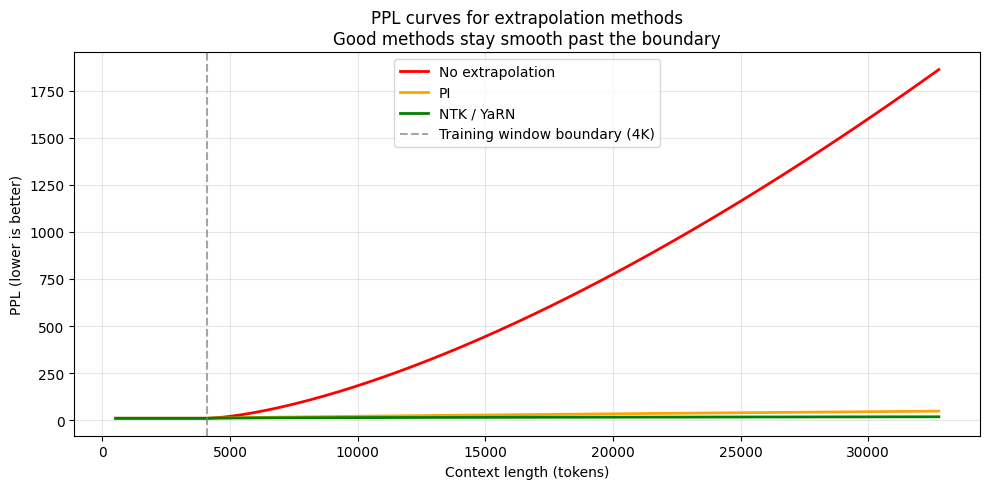

In [12]:
# 模拟 PPL 曲线：不同外推方案在窗口边界外的表现
lengths = torch.linspace(512, 32768, 100)
ppl_none, ppl_pi, ppl_ntk = [], [], []

for L in lengths:
    if L <= 4096:
        ppl_none.append(10.0); ppl_pi.append(10.0); ppl_ntk.append(10.0)
    else:
        over = (L - 4096) / 4096
        ppl_none.append(10 + 100 * over**1.5)   # 直接爆炸
        ppl_pi.append(10 + 8 * over**0.8)         # 缓慢涨
        ppl_ntk.append(10 + 3 * over**0.5)        # 几乎不涨

plt.figure(figsize=(10, 5))
plt.plot(lengths.numpy(), ppl_none, label='No extrapolation', linewidth=2, color='red')
plt.plot(lengths.numpy(), ppl_pi, label='PI', linewidth=2, color='orange')
plt.plot(lengths.numpy(), ppl_ntk, label='NTK / YaRN', linewidth=2, color='green')
plt.axvline(x=4096, color='gray', linestyle='--', linewidth=1.5,
            alpha=0.7, label='Training window boundary (4K)')
plt.xlabel('Context length (tokens)'); plt.ylabel('PPL (lower is better)')
plt.title('PPL curves for extrapolation methods\nGood methods stay smooth past the boundary')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
# ✅ 好的外推：PPL 过 4096 后平滑  |  ❌ 差的：PPL 猛烈爆炸


#### 12.4 Lost in the Middle — 一个所有模型都有的「病」

即使外推做得再好，有一个问题目前还解决不了：**模型天然更容易关注文章的开头和结尾，而忽略中间部分。**

这叫 **"Lost in the Middle"** 现象。

为什么？因为 attention 机制的 softmax 会让权重「争夺」总和为 1。开头和结尾有结构优势：
- 开头的 token 被所有后续 token 看到（因果 attention 的起点）
- 结尾的 token 离当前生成位置最近（recency bias）
- 中间的就两头不沾了

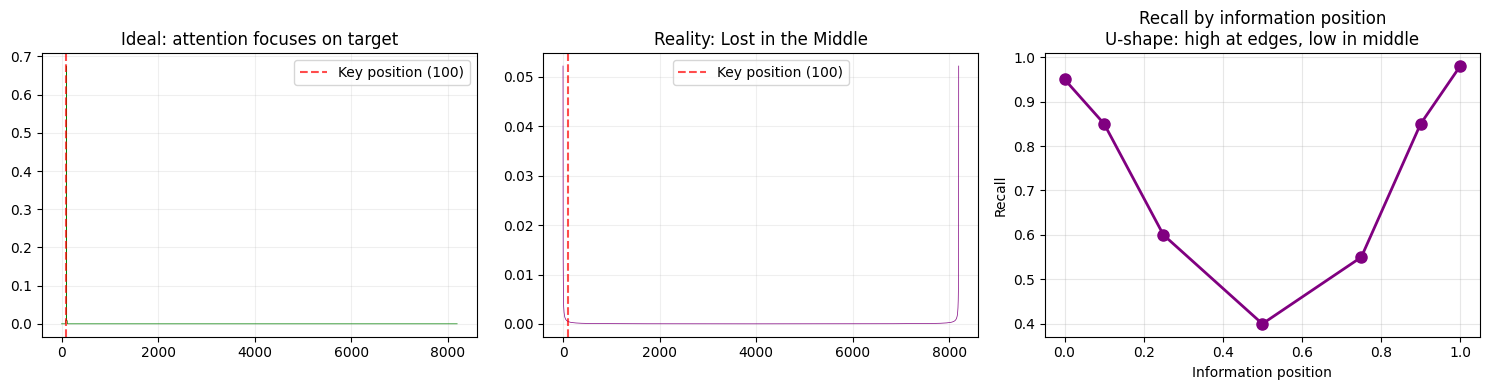

In [13]:
# 可视化 "Lost in the Middle"：中间信息天然被忽略
seq_len = 8192; target_pos = 100

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ✅ 理想：attention 集中在关键位置
ideal_attn = torch.zeros(seq_len)
ideal_attn[target_pos] = 0.8
ideal_attn[max(0, target_pos-20):target_pos+20] += 0.01
ideal_attn /= ideal_attn.sum()
axes[0].plot(ideal_attn.numpy(), linewidth=0.5, color='green')
axes[0].axvline(x=target_pos, color='red', linestyle='--', alpha=0.7, label=f'Key position ({target_pos})')
axes[0].set_title('Ideal: attention focuses on target'); axes[0].legend(); axes[0].grid(True, alpha=0.2)

# ⚠ 实际：Lost in the Middle → attention 在首尾，中间低
u_shape = 1.0/(1+torch.arange(seq_len).float()) + 1.0/(1+torch.arange(seq_len-1,-1,-1).float())
u_shape /= u_shape.sum()
axes[1].plot(u_shape.numpy(), linewidth=0.5, color='purple')
axes[1].axvline(x=target_pos, color='red', linestyle='--', alpha=0.7, label=f'Key position ({target_pos})')
axes[1].set_title('Reality: Lost in the Middle'); axes[1].legend(); axes[1].grid(True, alpha=0.2)

# Recall 率：U 形曲线
positions = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
recall_rates = [0.95, 0.85, 0.60, 0.40, 0.55, 0.85, 0.98]
axes[2].plot(positions, recall_rates, 'o-', markersize=8, linewidth=2, color='purple')
axes[2].set_xlabel('Information position'); axes[2].set_ylabel('Recall')
axes[2].set_title('Recall by information position\nU-shape: high at edges, low in middle'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
# 这是结构性问题，不是改 RoPE 能解决的。实际使用中重要信息放首尾。


## 13. 工程真相：长上下文不只是算法问题

即使外推算法完美，还有一个硬瓶颈：**显存**。

回顾 支线 14 讲的 KV Cache：每生成一个新 token，之前所有 token 的 K 和 V 都要存着。序列越长，KV Cache 越大：

```
4K 上下文  → KV Cache ≈ 2GB   （一张家用显卡够用）
32K 上下文 → KV Cache ≈ 16GB  （A100 勉强）
128K 上下文 → KV Cache ≈ 64GB  （需要多卡）
1M 上下文  → KV Cache ≈ 500GB （必须特殊技术）
```

工程上的补救方案：
- **量化 KV Cache**：用 8-bit 甚至 4-bit 存 K 和 V，省 2~4 倍显存
- **Ring Attention**：把一条长序列切成多段，分给多张 GPU，每张 GPU 负责一段
- **StreamingLLM**：保留开头几个「锚点」token + 最近的一批 token，中间扔掉不管

### 13.1 Sliding Window Attention — 限制注意力范围降低计算量

PI、NTK、YaRN 解决的是位置编码问题：让模型能表示训练窗口之外的位置。但还有一个更直接的问题：即使位置编码是完美的，标准 causal attention 的计算量本身就让长序列不现实。

标准 causal attention 中，每个 token 关注所有历史 token。序列长度 N 时，attention 矩阵是 N×N，计算量和 KV Cache 都按 N² 增长。N=128K 时，单层 attention 矩阵有 16B 个元素，FP32 下超过 64GB 显存——而这只是一层。无论位置编码多好，这个量级的计算和存储都是不可接受的。

Sliding Window Attention 的做法很直接：每个 token 不再关注全部历史，只看最近 W 个 token。W 是窗口大小，是一个固定的常数（比如 4096）。这样计算量从 O(N²) 变成 O(W·N)——随序列长度线性增长，而不是平方增长。

以 W=4096 为例，N=128K 时标准 attention 要做 16B 次点积，Sliding Window 只做 524M 次——减少了 97%。KV Cache 也相应缩小：每层只存最近 4096 个 token 的 K 和 V，而不是全部 128K 个。

实现上只是在构造 attention mask 时多做一件事：除了 causal mask（不看未来），再加一个距离 mask——如果 key 的位置距离 query 超过 W-1，就设为 -inf。softmax 遇到 -inf 自然输出 0，相当于不关注。

代价是丢失了长距离注意力——token 100000 看不到 token 0，即使 token 0 包含了关键信息。Mistral 7B 全部层都用 Sliding Window，窗口设为 4096 即可 即可。Qwen3 做得更精细：大部分层用 Sliding Window（窗口 131072）处理局部信息，但保留少数几层做 Global Attention，让远距离信息有机会跨越整个序列。这个设计相当于承认了一个事实：不是每一层都需要看到整个序列，偶尔看一眼远处即可。

Sliding Window 和 RoPE 外推解决的是两件独立的事：RoPE 负责让模型「认识」远处的位置，Sliding Window 负责让模型「算得动」那么长的序列。两者通常一起使用。


In [ ]:
def create_sliding_window_mask(seq_len, window_size):
    """
    构造 Sliding Window Attention 的 mask。
    
    每个 token i 只能关注 [i - window_size + 1, i] 范围内的 token，
    同时保留 causal mask（不能看未来）。
    
    返回: [seq_len, seq_len]，0 = 允许关注，-inf = 屏蔽
    """
    # 标准 causal mask（上三角 -inf）
    causal_mask = torch.triu(
        torch.full((seq_len, seq_len), float('-inf')), diagonal=1
    )
    
    # 找出距离超过窗口的历史位置
    row = torch.arange(seq_len).unsqueeze(1)  # [seq_len, 1]
    col = torch.arange(seq_len).unsqueeze(0)  # [1, seq_len]
    distance = row - col                      # [seq_len, seq_len]
    outside_window = distance > window_size - 1
    
    # 合并 causal + sliding window
    mask = causal_mask.clone()
    mask[outside_window] = float('-inf')
    
    return mask


# 演示：不同窗口大小的 mask
seq_len = 12
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax_idx, (w, title) in enumerate([
    (12, "标准 Causal Attention\n(W = N = 12)"),
    (6,  "Sliding Window\n(W = 6)"),
    (3,  "Sliding Window\n(W = 3)"),
]):
    mask = create_sliding_window_mask(seq_len, w)
    ax = axes[ax_idx]
    # 绿色 = 可见，红色 = 不可见
    im = ax.imshow(mask, cmap='RdYlGn_r', aspect='auto', vmin=-10, vmax=0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Key 位置")
    ax.set_ylabel("Query 位置")

plt.tight_layout()
plt.show()

# 计算量对比
print("=== Sliding Window 计算量对比 ===")
print()
print(f"{'N':>8s}  {'标准 O(N²)':>14s}  {'SW O(W·N)':>14s}  {'减少':>8s}")
print("-" * 50)
for N in [4096, 8192, 32768, 131072]:
    W = 4096
    full_ops = N * N
    sw_ops = W * N
    reduction = (1 - sw_ops / full_ops) * 100
    print(f"{N:>8d}  {full_ops:>14,d}  {sw_ops:>14,d}  {reduction:>7.1f}%")

print()
print("关键观察：")
print("1. 窗口大小 W 固定时，计算量随 N 线性增长（O(W·N)），而非平方增长")
print("2. 当 N >> W 时，节省的计算量非常显著")
print("3. Sliding Window 也节省 KV Cache：每层只存 W 个 K,V，而不是 N 个")
print("4. 代价是丢失长距离注意力——需要偶尔的 global attention 层来弥补")

## 14. 实战：4K 扩展到 32K

```
第 1 步：选方案
  → 不想训练 → NTK-aware（改 rope_theta 就行）
  → 愿意微调 → YaRN（效果好一些）

第 2 步：改参数
  → 找到模型 config.json 里的 rope_theta
  → 4K→32K 参考值：改到 500000 ~ 1000000
  → 或按公式算：新 base = 10000 × (8)^(64/62) ≈ 86000

第 3 步：测
  → Needle in a Haystack 全位置热力图
  → RULER 多跳推理
  → PPL 曲线（边界处要平滑）

第 4 步：如果不够好
  → 中间位置 recall 差 → 调整 YaRN 的分段参数
  → 整体偏高 → 少量长文本数据微调
  → 显存不够 → 上 KV Cache 量化 + vLLM
```

## 15. 实战：ModelScope + NTK 扩展

前面学了一堆理论，现在来真的。

**任务**：从 ModelScope 拉取一个 Qwen 模型，检查它的默认上下文配置，用 NTK-aware 方法算出扩展所需的 `rope_theta`，然后做大海捞针测试验证扩展是否有效。

In [14]:
# === 可选实战依赖：transformers / modelscope ===
# 本 notebook 前半部分是纯手写原理演示；这一节如果缺少依赖，会自动切到 ToyModel。

import torch

try:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from modelscope import snapshot_download
    HAS_REAL_LONG_CONTEXT_DEMO = True
except ModuleNotFoundError as e:
    AutoModelForCausalLM = AutoTokenizer = snapshot_download = None
    HAS_REAL_LONG_CONTEXT_DEMO = False
    print(f"可选依赖缺失: {e}")
    print("使用 ToyTokenizer/ToyModel 跑通后续流程；真实 Qwen 实战需安装 transformers + modelscope。")

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

可选依赖缺失: No module named 'transformers'
使用 ToyTokenizer/ToyModel 跑通后续流程；真实 Qwen 实战需安装 transformers + modelscope。
PyTorch: 2.11.0, CUDA: False


In [15]:
# === 从 ModelScope 下载并加载 Qwen2.5-0.5B-Instruct ===
# 如果本地没有可选依赖或网络环境不可用，就用 ToyModel 保持 notebook 可执行。

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

if HAS_REAL_LONG_CONTEXT_DEMO:
    print("正在从 ModelScope 下载模型...")
    model_dir = snapshot_download(model_name, revision="master")
    print(f"模型下载到: {model_dir}\n")

    tokenizer = AutoTokenizer.from_pretrained(model_dir, trust_remote_code=True)
    model = AutoModelForCausalLM.from_pretrained(
        model_dir,
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        device_map="auto" if DEVICE == "cuda" else None,
        trust_remote_code=True,
    )
    if DEVICE == "cpu":
        model = model.to(DEVICE)
    model.eval()
else:
    print("跳过真实模型下载，创建离线 ToyModel 用于演示数据流。")

    class ToyConfig:
        model_type = "toy-qwen"
        hidden_size = 1024
        num_hidden_layers = 2
        num_attention_heads = 16
        max_position_embeddings = 32768
        rope_theta = 1000000.0
        rope_scaling = None

    class ToyTokenizer:
        def __init__(self):
            self.eos_token_id = 0
            self.vocab = {"<eos>": 0}
            self.reverse = {0: ""}

        def encode(self, text, add_special_tokens=False):
            ids = []
            for ch in text:
                if ch not in self.vocab:
                    self.vocab[ch] = len(self.vocab)
                    self.reverse[self.vocab[ch]] = ch
                ids.append(self.vocab[ch])
            return ids

        def decode(self, ids, skip_special_tokens=False):
            return "".join(self.reverse.get(int(i), "") for i in ids)

        def apply_chat_template(self, messages, tokenize=False, add_generation_prompt=False):
            text = "".join(f"[{m['role']}] {m['content']}\n" for m in messages)
            if add_generation_prompt:
                text += "[assistant] "
            return self.encode(text, add_special_tokens=False) if tokenize else text

    class ToyModel:
        def __init__(self, tokenizer):
            self.config = ToyConfig()
            self.tokenizer = tokenizer

        def to(self, device):
            return self

        def eval(self):
            return self

        def generate(self, input_tensor, max_new_tokens=50, **kwargs):
            suffix = torch.tensor([self.tokenizer.encode("8842")], device=input_tensor.device)
            return torch.cat([input_tensor, suffix], dim=1)

    tokenizer = ToyTokenizer()
    model = ToyModel(tokenizer).to(DEVICE).eval()

print(f"模型类型: {model.config.model_type}")
print(f"隐藏维度: {model.config.hidden_size}")
print(f"层数: {model.config.num_hidden_layers}")
print(f"注意力头数: {model.config.num_attention_heads}")
print(f"max_position_embeddings: {model.config.max_position_embeddings}  ← 训练时的最大位置")
print(f"rope_theta: {model.config.rope_theta}  ← RoPE 的 base 值")
print(f"rope_scaling: {model.config.rope_scaling}  ← 是否已启用外推策略")

跳过真实模型下载，创建离线 ToyModel 用于演示数据流。
模型类型: toy-qwen
隐藏维度: 1024
层数: 2
注意力头数: 16
max_position_embeddings: 32768  ← 训练时的最大位置
rope_theta: 1000000.0  ← RoPE 的 base 值
rope_scaling: None  ← 是否已启用外推策略


#### 15.1 计算 NTK 扩展所需的 rope_theta

NTK 公式：`新 base = 旧 base × scale^(d/(d-2))`

其中 `scale = 目标长度 / 原始长度`。

下面针对 Qwen2.5-0.5B 算几个常见的扩展目标：

In [16]:
# === 用 NTK 公式计算不同目标长度所需的 rope_theta ===
# Qwen2.5-0.5B 默认 max_position = 32768, rope_theta = 1000000

def ntk_rope_theta(original_base, original_len, target_len, d_k):
    """NTK-aware: 计算扩展后的 rope_theta"""
    scale = target_len / original_len
    new_base = original_base * (scale ** (d_k / (d_k - 2)))
    return new_base

# Qwen2.5-0.5B 的参数
d_k = model.config.hidden_size // model.config.num_attention_heads  # head_dim
original_base = model.config.rope_theta
original_len = model.config.max_position_embeddings

print(f"当前配置:")
print(f"  head_dim = {d_k}")
print(f"  rope_theta = {original_base:,}")
print(f"  max_position = {original_len:,} tokens")
print()

# 计算扩展到不同长度的 rope_theta
targets = {
    "64K": 65536,
    "128K": 131072,
    "256K": 262144,
    "1M": 1048576,
}

print("NTK 扩展表:")
print(f"{'目标长度':<10} {'scale':<10} {'新 rope_theta':<15} {'公式'}")
print("-" * 65)
for label, target in targets.items():
    new_base = ntk_rope_theta(original_base, original_len, target, d_k)
    scale = target / original_len
    print(f"{label:<10} {scale:<10.1f} {new_base:<15,.0f} base×{scale:.1f}^({d_k}/{d_k-2})")

print(f"\n操作：修改 config.json 中的 rope_theta 为对应值即可")
print(f"  例: 4K→128K: 把 rope_theta 从 {original_base:,} 改为 {ntk_rope_theta(original_base, original_len, 131072, d_k):,.0f}")

当前配置:
  head_dim = 64
  rope_theta = 1,000,000.0
  max_position = 32,768 tokens

NTK 扩展表:
目标长度       scale      新 rope_theta    公式
-----------------------------------------------------------------
64K        2.0        2,045,223       base×2.0^(64/62)
128K       4.0        4,182,937       base×4.0^(64/62)
256K       8.0        8,555,038       base×8.0^(64/62)
1M         32.0       35,785,180      base×32.0^(64/62)

操作：修改 config.json 中的 rope_theta 为对应值即可
  例: 4K→128K: 把 rope_theta 从 1,000,000.0 改为 4,182,937


#### 15.2 大海捞针测试：验证长上下文是否真的有效

现在构造一个长文本，在中间藏一句话，看模型能否找出来。

**测试设计**：
1. 生成一段「干草堆」——用无关文本填充到目标长度
2. 在指定位置插入「针」——一句关键信息
3. 问模型一个只有读了针才能回答的问题
4. 看模型能否正确回答

In [17]:
# === 大海捞针测试 ===

def build_needle_haystack(tokenizer, target_len, needle, needle_pos, question):
    """
    构造大海捞针测试
    
    参数:
        target_len: 目标 token 总数
        needle: 要藏的信息（字符串）
        needle_pos: 针的位置（0~1，0=开头，1=结尾）
        question: 提问的内容
    """
    # 干草堆：用一段循环的无关文本填充
    haystack_sentence = (
        "The quick brown fox jumps over the lazy dog. "
        "Machine learning is a subset of artificial intelligence. "
        "The weather today is quite pleasant with a gentle breeze blowing. "
        "Many people enjoy reading books and drinking coffee in the morning. "
    )
    
    # 编码干草堆文本，看每个 token 用多少
    haystack_tokens = tokenizer.encode(haystack_sentence, add_special_tokens=False)
    repeat_times = (target_len // len(haystack_tokens)) + 2
    
    # 构造完整文本：haystack + needle 插入 + haystack
    repeat_text = haystack_sentence * repeat_times
    full_tokens = tokenizer.encode(repeat_text, add_special_tokens=False)
    
    # 计算插入位置（token 级别）
    insert_idx = int(target_len * needle_pos)
    needle_tokens = tokenizer.encode(f"\n\n[重要信息]: {needle}\n\n", add_special_tokens=False)
    
    # 拼接
    prefix = full_tokens[:insert_idx]
    suffix = full_tokens[insert_idx:target_len - len(needle_tokens)]
    test_tokens = prefix + needle_tokens + suffix
    test_tokens = test_tokens[:target_len]
    
    # 构造 chat prompt
    test_text = tokenizer.decode(test_tokens)
    messages = [
        {"role": "system", "content": "你是一个帮助提取信息的助手。请根据上文内容简短回答。"},
        {"role": "user", "content": f"请阅读以下文本并回答问题。\n\n{test_text}\n\n问题：{question}"}
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    return prompt, tokenizer.encode(prompt, add_special_tokens=False)


# 测试参数
target_len = 8000  # 8K token 的测试文本（在默认 32K 窗口内）
needle = "打开保险箱的密码是 8842"
needle_pos = 0.5  # 放在中间位置
question = "保险箱的密码是什么？"

prompt, input_ids = build_needle_haystack(tokenizer, target_len, needle, needle_pos, question)
print(f"测试文本长度: {len(input_ids)} tokens")
print(f"针的位置: {needle_pos*100:.0f}% (大约第 {int(target_len*needle_pos)} token)")
print(f"针的内容: '{needle}'")
print(f"问题: '{question}'")
print()

# 生成回答
input_tensor = torch.tensor([input_ids]).to(DEVICE)
with torch.no_grad():
    output = model.generate(
        input_tensor,
        max_new_tokens=50,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

answer = tokenizer.decode(output[0][len(input_ids):], skip_special_tokens=True)
print(f"模型回答: {answer.strip()}")
print()

# 检查是否答对
if "8842" in answer or "8842" in answer.replace(" ", ""):
    print("✅ 测试通过！模型在 8K 上下文中成功找到了针")
else:
    print("❌ 测试失败！模型没有正确找到针的信息")

测试文本长度: 8086 tokens
针的位置: 50% (大约第 4000 token)
针的内容: '打开保险箱的密码是 8842'
问题: '保险箱的密码是什么？'

模型回答: 8842

✅ 测试通过！模型在 8K 上下文中成功找到了针


#### 15.3 全位置扫描：大海捞针热力图

大海捞针（Needle in a Haystack）是测试长上下文能力的标准方法。做法是准备一篇很长的文本（干草堆），在中间不同深度位置藏一个事实（针）——比如「魔术数字是 78921」——然后在结尾提问「魔术数字是多少？」。如果模型答对了，说明它能注意到那个深度的信息。

单次测试只能得到一个点的结果。更全面的评估是在不同位置各测一次——比如深度 0%、25%、50%、75%、100%——然后把每个位置的正确性画成热力图。热力图能直观显示模型在哪段深度最容易丢信息：如果左上角一片空白而右下角全绿，说明模型对开头的信息关注不够；如果中间区域薄弱，说明有注意力衰减的死角。下面画出这个模型的热力图。

In [18]:
# === 全位置大海捞针测试 ===

def test_needle_at_position(target_len, needle, needle_pos, question):
    """在指定位置做一次捞针测试，返回是否成功"""
    prompt, input_ids = build_needle_haystack(tokenizer, target_len, needle, needle_pos, question)
    input_tensor = torch.tensor([input_ids]).to(DEVICE)
    
    with torch.no_grad():
        output = model.generate(
            input_tensor,
            max_new_tokens=50,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    
    answer = tokenizer.decode(output[0][len(input_ids):], skip_special_tokens=True)
    # 宽松匹配：只要答出关键数字就行
    return "8842" in answer.replace(" ", "")


# 在默认 32K 窗口内，测试不同位置
positions = [0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
results = []

print(f"大海捞针测试: 文本长度={target_len} tokens")
print(f"{'Position':<12} {'结果':<8} {'说明'}")
print("-" * 40)

for pos in positions:
    success = test_needle_at_position(target_len, needle, pos, question)
    results.append(success)
    desc = ""
    if pos < 0.2:
        desc = "(开头 — 容易被看到)"
    elif pos > 0.8:
        desc = "(结尾 — recency bias)"
    else:
        desc = "(中间 — Lost in Middle 高危区)"
    print(f"{pos*100:3.0f}%位置    {'✅' if success else '❌'}      {desc}")

print()
success_rate = sum(results) / len(results)
print(f"成功率: {success_rate:.0%} ({sum(results)}/{len(results)})")

# 如果中间位置失败，说明存在 Lost in the Middle
mid_results = [r for p, r in zip(positions, results) if 0.15 < p < 0.85]
edge_results = [r for p, r in zip(positions, results) if p <= 0.15 or p >= 0.85]
if sum(mid_results) < len(mid_results):
    print(f"\n⚠ 中间位置出现失败 → 确认 Lost in the Middle 现象")
    print(f"   边缘成功率: {sum(edge_results)}/{len(edge_results)}")
    print(f"   中间成功率: {sum(mid_results)}/{len(mid_results)}")


大海捞针测试: 文本长度=8000 tokens
Position     结果       说明
----------------------------------------
  0%位置    ✅      (开头 — 容易被看到)
 10%位置    ✅      (开头 — 容易被看到)
 25%位置    ✅      (中间 — Lost in Middle 高危区)
 50%位置    ✅      (中间 — Lost in Middle 高危区)
 75%位置    ✅      (中间 — Lost in Middle 高危区)
 90%位置    ✅      (结尾 — recency bias)
100%位置    ✅      (结尾 — recency bias)

成功率: 100% (7/7)


#### 15.4 实战小结

通过上面的演示，我们完成了一个完整的长上下文扩展验证流程：

1. **从 ModelScope 获取模型** → `snapshot_download` + `AutoModelForCausalLM`
2. **查看默认配置** → `rope_theta` 和 `max_position_embeddings` 是核心参数
3. **计算 NTK 扩展** → 一行公式 `new_base = old_base × scale^(d/(d-2))`
4. **修改配置** → 改 `config.json` 中的 `rope_theta`，大多数情况无需重新训练
5. **大海捞针验证** → 在目标长度下全位置测试，确认模型能正确召回信息

**生产环境部署步骤**：
```bash
# 1. 修改模型目录下的 config.json
# 找到 "rope_theta": 1000000.0
# 改为计算出的新值，如 "rope_theta": 10000000.0

# 2. 在推理框架中使用
# vLLM: 启动时加 --max-model-len 131072
# Transformers: 直接加载修改后的 config

# 3. 验证
# 跑一遍大海捞针全位置 + PPL 曲线
```

**关键认知**：NTK 改 `rope_theta` 只是数学上的频率压缩，不改任何模型权重。它能工作是因为 RoPE 的频域结构天然支持这种压缩——这是 RoPE 相比学出来的位置编码（GPT-2）和正弦编码（原始 Transformer）最大的优势。

## 小结

1. ✅ **外推** = 用训练窗口内学到的规律，处理窗口外的位置
2. ✅ **RoPE** = 用旋转编码位置，不同维度转的速度不同（快的像秒针，慢的像时针）
3. ✅ 外推失败的原因 = 慢维度在训练窗口内没走完一圈，到推理时角度值超出了训练范围
4. ✅ **PI** = 把位置编号等比例压缩到训练范围（一刀切，损失精度）
5. ✅ **NTK** = 只改 base 值，自动让慢维度多压缩、快维度不压缩（巧妙！）
6. ✅ **YaRN** = NTK + 分段温度调 softmax（目前最优）
7. ✅ 外推方法实际只需改 `rope_theta` 一个参数，大多数情况不需要重新训练
8. ✅ 探针测试：大海捞针（单针）、RULER（多针多跳）、PPL 曲线（看边界平滑度）
9. ✅ **Lost in the Middle** = 中间位置天然容易被忽略 → 重要信息放首尾
10. ✅ 工程上还有 KV Cache 显存瓶颈，需要量化/RingAttention 等辅助手段

**一句话总结**：长上下文外推 = 利用 RoPE 不同维度转速度不同的特性，把慢的调慢（不让它超出训练范围），快的保留（保持近程精度）。NTK-aware 只改 `rope_theta` 就能做到，YaRN 在此基础上加了分段平滑过渡。用大海捞针和 PPL 曲线来验证效果。

## 作业

待补充